# Fine-Tuning a Vision Language Model for Drone Image Understanding and VQA **Model:** Qwen2-VL-2B-Instruct | **Method:** QLoRA (4-bit + LoRA) | **Dataset:** VisDrone2019 (auto-generated VQA pairs). This notebook fine-tunes a Vision Language Model to answer questions about drone/aerial imagery — counting objects, detecting presence/absence of object categories, and identifying dominant object types — using parameter-efficient fine-tuning on a single free-tier Kaggle T4 GPU.

## 1. Setup and Imports

In [1]:
# ===================== IMPORTS =====================
import os
import json
import random
import time
import re
import torch
from collections import Counter
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel

random.seed(42)

In [2]:
!pip install -q -U transformers accelerate peft bitsandbytes qwen-vl-utils

## 2. Explore the VisDrone2019 DatasetVisDrone2019 provides drone-captured images with object-detection annotations (YOLO format: `class_id x_center y_center width height`, all normalized 0–1). We use these annotations to auto-generate VQA question-answer pairs.

In [ ]:
base = "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train"

images_dir = f"{base}/images"
labels_dir = f"{base}/labels"

image_files = sorted(os.listdir(images_dir))
label_files = sorted(os.listdir(labels_dir))

print("Number of images:", len(image_files))
print("Number of labels:", len(label_files))
print("Sample image filename:", image_files[0])
print("Sample label filename:", label_files[0])

# Print contents of the first label file
with open(f"{labels_dir}/{label_files[0]}") as f:
    content = f.read()
print("\nLabel file content (first 500 chars):")
print(content[:500])

In [ ]:
yaml_path = "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/visdrone.yaml"
with open(yaml_path) as f:
    print(f.read())

## 3. Generate VQA Pairs from Object Annotations. For each image, we parse its label file to get object counts per category, then generate four types of natural-language question-answer pairs: **counting**, **existence** (Yes/No), **most common object**, and **total object count**. Grammar rules (pluralization, articles, singular/plural handling) ensure natural-sounding questions.

In [ ]:
CLASS_NAMES = {
    0: "pedestrian", 1: "people", 2: "bicycle", 3: "car", 4: "van",
    5: "truck", 6: "tricycle", 7: "awning-tricycle", 8: "bus", 9: "motor"
}

# Correct plural forms for natural-sounding questions
PLURALS = {
    "pedestrian": "pedestrians",
    "people": "people",          # already plural
    "bicycle": "bicycles",
    "car": "cars",
    "van": "vans",
    "truck": "trucks",
    "tricycle": "tricycles",
    "awning-tricycle": "awning-tricycles",
    "bus": "buses",
    "motor": "motors"
}

# Special-case singular form for existence questions where the class name is "people"
SINGULAR_FOR_EXISTENCE = {
    "people": "person"
}

def article_for(word):
    """Returns 'an' or 'a' depending on the first letter."""
    return "an" if word[0].lower() in "aeiou" else "a"

def parse_label_file(label_path):
    """Returns a Counter of class_name -> count for one image."""
    counts = Counter()
    if not os.path.exists(label_path):
        return counts
    with open(label_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            class_id = int(line.split()[0])
            class_name = CLASS_NAMES.get(class_id)
            if class_name:
                counts[class_name] += 1
    return counts

def generate_vqa_pairs(counts, image_filename):
    """Given object counts for an image, generate a list of (question, answer) pairs."""
    pairs = []
    present_classes = list(counts.keys())
    absent_classes = [c for c in CLASS_NAMES.values() if c not in counts]

    # 1. Counting questions - one per class present, plus a couple of zero-count examples
    for cls in present_classes:
        plural = PLURALS[cls]
        pairs.append((f"How many {plural} are in this image?", str(counts[cls])))
    for cls in random.sample(absent_classes, min(2, len(absent_classes))):
        plural = PLURALS[cls]
        pairs.append((f"How many {plural} are in this image?", "0"))

    # 2. Existence questions
    for cls in present_classes:
        singular = SINGULAR_FOR_EXISTENCE.get(cls, cls)
        art = article_for(singular)
        pairs.append((f"Is there {art} {singular} in this image?", "Yes"))
    for cls in random.sample(absent_classes, min(2, len(absent_classes))):
        singular = SINGULAR_FOR_EXISTENCE.get(cls, cls)
        art = article_for(singular)
        pairs.append((f"Is there {art} {singular} in this image?", "No"))

    # 3. Most common object
    if counts:
        most_common = counts.most_common(1)[0][0]
        pairs.append(("What is the most common object in this image?", most_common))

    # 4. Total object count
    total = sum(counts.values())
    pairs.append(("How many objects are in this image in total?", str(total)))

    return pairs

# Quick test on the first image
sample_label_path = f"{labels_dir}/{label_files[0]}"
counts = parse_label_file(sample_label_path)
pairs = generate_vqa_pairs(counts, image_files[0])
print(f"Generated {len(pairs)} VQA pairs:\n")
for q, a in pairs:
    print(f"  Q: {q}\n  A: {a}\n")

## 4. Build and Save the Full Dataset. We subsample **900 training images** and **150 validation images** (fixed seed for reproducibility) to keep dataset size manageable for training within Kaggle's free GPU time budget, while still producing a large, diverse set of QA pairs.

In [ ]:
random.seed(42)  # for reproducibility - important to mention in your report

def build_dataset(images_dir, labels_dir, num_images, split_name):
    all_images = sorted(os.listdir(images_dir))
    sampled_images = random.sample(all_images, min(num_images, len(all_images)))

    dataset = []
    skipped = 0

    for img_filename in sampled_images:
        label_filename = img_filename.rsplit(".", 1)[0] + ".txt"
        label_path = os.path.join(labels_dir, label_filename)

        if not os.path.exists(label_path):
            skipped += 1
            continue

        counts = parse_label_file(label_path)
        if not counts:  # skip images with no objects at all
            skipped += 1
            continue

        pairs = generate_vqa_pairs(counts, img_filename)

        for question, answer in pairs:
            dataset.append({
                "image_filename": img_filename,
                "question": question,
                "answer": answer
            })

    print(f"[{split_name}] Sampled {len(sampled_images)} images, skipped {skipped}, "
          f"generated {len(dataset)} QA pairs")
    return dataset

# Paths
train_images_dir = f"{base}/images"
train_labels_dir = f"{base}/labels"

val_base = "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val"
val_images_dir = f"{val_base}/images"
val_labels_dir = f"{val_base}/labels"

# Build datasets
train_data = build_dataset(train_images_dir, train_labels_dir, num_images=900, split_name="train")
val_data = build_dataset(val_images_dir, val_labels_dir, num_images=150, split_name="val")

# Save to disk (persisted across sessions if persistence is enabled)
os.makedirs("/kaggle/working/vqa_data", exist_ok=True)

with open("/kaggle/working/vqa_data/train.json", "w") as f:
    json.dump(train_data, f, indent=2)

with open("/kaggle/working/vqa_data/val.json", "w") as f:
    json.dump(val_data, f, indent=2)

print("\nSaved train.json and val.json to /kaggle/working/vqa_data/")
print(f"\nSample entries:")
for entry in train_data[:3]:
    print(entry)

## 5. Load the Base Model (4-bit Quantized). We load **Qwen2-VL-2B-Instruct** using 4-bit NF4 quantization (via `bitsandbytes`), which shrinks the model's GPU memory footprint enough to fit and fine-tune on a single 16 GB Tesla T4. We also cap the image resolution (`min_pixels`/`max_pixels`) to control the number of image tokens generated per image — without this cap, a single image could produce 7,000+ image tokens, drastically inflating memory use and training time.

In [ ]:
model_id = "Qwen/Qwen2-VL-2B-Instruct"

# 4-bit quantization config - this is what makes it fit on a T4
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading model...")

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map={"": 0},   # pin to a single GPU - avoids slow cross-GPU splitting
)

processor = AutoProcessor.from_pretrained(
    model_id,
    min_pixels=256*256,
    max_pixels=640*640,
)

print("Model loaded on:", next(model.parameters()).device)
print("Model memory footprint (GB):", model.get_memory_footprint() / 1e9)

## 6. Configure LoRA (Parameter-Efficient Fine-Tuning). Instead of updating all 2.2 billion parameters, LoRA adds small trainable low-rank matrices to the attention projection layers, freezing everything else. This trains under 0.2% of total parameters while still allowing meaningful adaptation.

In [ ]:
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,                      # rank - higher = more capacity but more memory
    lora_alpha=32,              # scaling factor, commonly 2x the rank
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # attention layers
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

## 7. Dataset Class and Collate FunctionThe `DroneVQADataset` wraps each (image, question, answer) example into the conversation format Qwen2-VL expects. The `collate_fn` tokenizes batches and — critically — masks the loss so the model only learns to predict the **answer** tokens, not the question or image tokens. This required locating the assistant-turn marker directly within the fully tokenized sequence to get correct, minimal label spans.

In [ ]:
class DroneVQADataset(Dataset):
    def __init__(self, data, images_dir, processor):
        self.data = data
        self.images_dir = images_dir
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image_path = os.path.join(self.images_dir, item["image_filename"])
        image = Image.open(image_path).convert("RGB")
        question = item["question"]
        answer = item["answer"]

        conversation = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": question},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": answer}],
            },
        ]

        return {"image": image, "conversation": conversation}


def collate_fn(batch, processor):
    texts = []
    images = []

    for item in batch:
        text = processor.apply_chat_template(item["conversation"], tokenize=False)
        texts.append(text)
        images.append(item["image"])

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )

    labels = inputs["input_ids"].clone()
    labels[:] = -100  # mask everything by default

    # Qwen2-VL chat template marks assistant turns with "<|im_start|>assistant\n"
    assistant_marker = "<|im_start|>assistant\n"
    marker_ids = processor.tokenizer(assistant_marker, add_special_tokens=False)["input_ids"]
    marker_len = len(marker_ids)

    for i in range(len(batch)):
        full_ids = inputs["input_ids"][i].tolist()
        real_len = int(inputs["attention_mask"][i].sum().item())
        real_ids = full_ids[:real_len]

        # Find where the assistant marker occurs in the real (non-padded) tokens
        answer_start = None
        for pos in range(len(real_ids) - marker_len + 1):
            if real_ids[pos:pos + marker_len] == marker_ids:
                answer_start = pos + marker_len
                break

        if answer_start is None:
            continue  # safety fallback - shouldn't happen

        labels[i, answer_start:real_len] = torch.tensor(real_ids[answer_start:real_len])

    inputs["labels"] = labels
    return inputs


train_dataset = DroneVQADataset(train_data, train_images_dir, processor)
val_dataset = DroneVQADataset(val_data, val_images_dir, processor)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))

## 8. Train the Model

In [ ]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/qwen2vl_drone_lora",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    max_steps=500,
    learning_rate=5e-5,
    logging_steps=10,
    save_steps=100,
    save_total_limit=2,
    eval_strategy="steps",
    eval_steps=100,
    fp16=True,
    gradient_checkpointing=False,
    report_to="none",
    remove_unused_columns=False,
    dataloader_num_workers=0,
    warmup_steps=20,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=lambda batch: collate_fn(batch, processor),
)

print("Launching training: 500 steps, ~5-6 hours estimated")

start = time.time()
trainer.train()
elapsed = time.time() - start

print(f"\nTraining complete! Total time: {elapsed/3600:.2f} hours")

In [ ]:
# Full training log (for inspection / plotting)
log_history = trainer.state.log_history
for entry in log_history:
    step = entry.get("step", "?")
    if "loss" in entry:
        print(f"  Step {step}: train_loss = {entry['loss']:.4f}")
    if "eval_loss" in entry:
        print(f"  Step {step}: eval_loss = {entry['eval_loss']:.4f}")

## 9. Save the Fine-Tuned LoRA Adapter

In [ ]:
save_path = "/kaggle/working/qwen2vl_drone_lora_final"
model.save_pretrained(save_path)
processor.save_pretrained(save_path)

print("Saved adapter and processor to:", save_path)
print("Contents:", os.listdir(save_path))

## 10. Reload for Inference (Run This After Any New Session). If you're starting a fresh Kaggle session (after a restart, or on a new day), run this cell first to reload the dataset, base model, and your trained adapter cleanly. The `mean abs value` check confirms the adapter's trained weights (not a fresh/zero-initialized adapter) are actually loaded — it should **not** print `0.000000`.

In [3]:
from peft import PeftModel

random.seed(42)

with open("/kaggle/working/vqa_data/train.json") as f:
    train_data = json.load(f)
with open("/kaggle/working/vqa_data/val.json") as f:
    val_data = json.load(f)

train_images_dir = "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train/images"
val_images_dir = "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images"
adapter_path = "/kaggle/working/qwen2vl_drone_lora_final"
backup_checkpoint = "/kaggle/working/qwen2vl_drone_lora/checkpoint-500"
model_id = "Qwen/Qwen2-VL-2B-Instruct"

print(f"Loaded {len(train_data)} train examples, {len(val_data)} val examples")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map={"": 0},
)

processor = AutoProcessor.from_pretrained(
    adapter_path,
    min_pixels=256*256,
    max_pixels=640*640,
)

model = PeftModel.from_pretrained(base_model, adapter_path)
model.eval()

# --- Automatic safety check ---
lora_b_mean = None
for name, param in model.named_parameters():
    if "lora_B" in name:
        lora_b_mean = param.abs().mean().item()
        break

print(f"\nAdapter check - lora_B mean abs value: {lora_b_mean:.6f}")

if lora_b_mean == 0.0:
    print("\n⚠️  WARNING: Adapter appears UNTRAINED (all-zero lora_B weights).")
    print("Falling back to the backup training checkpoint instead...")
    base_model = Qwen2VLForConditionalGeneration.from_pretrained(
        model_id, quantization_config=bnb_config, torch_dtype=torch.float16, device_map={"": 0},
    )
    model = PeftModel.from_pretrained(base_model, backup_checkpoint)
    model.eval()
    for name, param in model.named_parameters():
        if "lora_B" in name:
            print(f"Backup checkpoint lora_B mean abs value: {param.abs().mean().item():.6f}")
            break
else:
    print("Adapter loaded correctly (trained weights confirmed).")

print("\nModel device:", next(model.parameters()).device)

Loaded 15360 train examples, 2892 val examples


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]


Adapter check - lora_B mean abs value: 0.000743
Adapter loaded correctly (trained weights confirmed).

Model device: cuda:0


## 11. Qualitative Test — Before vs. After Fine-Tuning A quick sanity check on a single example: before fine-tuning, the base model answered in a full sentence ("There is one bus in the image."); after fine-tuning, it answers directly, matching the terse format we trained it on.

In [6]:
def generate_answer(model, processor, image, question, max_new_tokens=20):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question},
            ],
        }
    ]
    text_prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = processor(text=[text_prompt], images=[image], return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    output_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return output_text.strip()


test_image_filename = train_data[0]["image_filename"]
test_question = train_data[1]["question"]
test_answer = train_data[1]["answer"]

image_path = os.path.join(train_images_dir, test_image_filename)
image = Image.open(image_path).convert("RGB")

print("Testing on:", test_image_filename)
print("Question:", test_question)
print("Ground truth answer:", test_answer)

answer = generate_answer(model, processor, image, test_question)

print("\nModel's answer (AFTER fine-tuning):", answer)
print("Recall, BEFORE fine-tuning the base model said: 'There is no car in the image.'")

Testing on: 9999985_00000_d_0000006.jpg
Question: How many cars are in this image?
Ground truth answer: 10

Model's answer (AFTER fine-tuning): 10
Recall, BEFORE fine-tuning the base model said: 'There is no car in the image.'


## 12. Quantitative Evaluation on the Validation Set We evaluate on a fixed random sample of 150 validation examples, scoring by category (counting, existence, most-common-object, total-count) using exact-match / first-number-extraction scoring.

In [7]:
def categorize_question(question):
    if question.startswith("Is there"):
        return "existence"
    elif question.startswith("What is the most common"):
        return "most_common"
    elif "in total" in question:
        return "total_count"
    elif question.startswith("How many"):
        return "counting"
    else:
        return "other"

def is_correct(predicted, ground_truth, category):
    predicted = predicted.strip().lower()
    ground_truth = ground_truth.strip().lower()

    if category == "counting" or category == "total_count":
        pred_nums = re.findall(r'\d+', predicted)
        pred_num = pred_nums[0] if pred_nums else None
        return pred_num == ground_truth
    else:
        return predicted == ground_truth


random.seed(123)
eval_sample = random.sample(val_data, 150)

results_by_category = {}
all_results = []

print("Running evaluation on 150 examples...")
start = time.time()

for idx, item in enumerate(eval_sample):
    image_path = os.path.join(val_images_dir, item["image_filename"])
    image = Image.open(image_path).convert("RGB")

    predicted = generate_answer(model, processor, image, item["question"])
    category = categorize_question(item["question"])
    correct = is_correct(predicted, item["answer"], category)

    all_results.append({
        "question": item["question"],
        "predicted": predicted,
        "ground_truth": item["answer"],
        "category": category,
        "correct": correct
    })

    results_by_category.setdefault(category, {"correct": 0, "total": 0})
    results_by_category[category]["total"] += 1
    if correct:
        results_by_category[category]["correct"] += 1

    if (idx + 1) % 25 == 0:
        elapsed = time.time() - start
        print(f"  Progress: {idx+1}/150 ({elapsed:.0f}s elapsed)")

print(f"\nTotal time: {(time.time()-start)/60:.1f} minutes")
print("\n=== ACCURACY BY CATEGORY ===")
for cat, stats in results_by_category.items():
    acc = stats["correct"] / stats["total"] * 100
    print(f"{cat}: {stats['correct']}/{stats['total']} = {acc:.1f}%")

overall_correct = sum(s["correct"] for s in results_by_category.values())
overall_total = sum(s["total"] for s in results_by_category.values())
print(f"\nOVERALL: {overall_correct}/{overall_total} = {overall_correct/overall_total*100:.1f}%")

with open("/kaggle/working/eval_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print("\nSaved detailed results to /kaggle/working/eval_results.json")

Running evaluation on 150 examples...
  Progress: 25/150 (15s elapsed)
  Progress: 50/150 (29s elapsed)
  Progress: 75/150 (45s elapsed)
  Progress: 100/150 (59s elapsed)
  Progress: 125/150 (74s elapsed)
  Progress: 150/150 (89s elapsed)

Total time: 1.5 minutes

=== ACCURACY BY CATEGORY ===
existence: 57/67 = 85.1%
counting: 23/70 = 32.9%
most_common: 3/7 = 42.9%
total_count: 0/6 = 0.0%

OVERALL: 83/150 = 55.3%

Saved detailed results to /kaggle/working/eval_results.json


## 13. Try Your Own Examples Pick any validation image and see the model answer all of its auto-generated questions at once.

Image: 0000289_05801_d_0000840.jpg


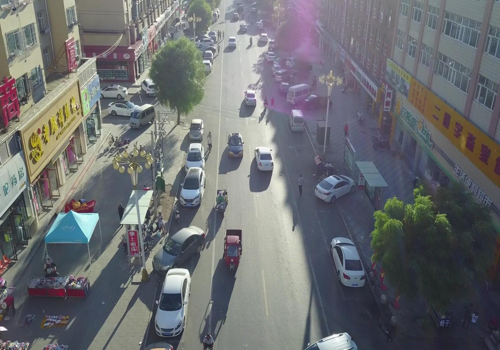

In [10]:
# Pick a random image from validation set and show ALL its questions
sample_image_filename = random.choice(val_data)["image_filename"]
questions_for_image = [item for item in val_data if item["image_filename"] == sample_image_filename]

image_path = os.path.join(val_images_dir, sample_image_filename)
image = Image.open(image_path).convert("RGB")

print("Image:", sample_image_filename)
image.resize((500, 350))

In [11]:
print(f"{len(questions_for_image)} questions available for this image:\n")
for item in questions_for_image:
    predicted = generate_answer(model, processor, image, item["question"])
    match = "✓" if predicted.strip().lower() == item["answer"].strip().lower() else "✗"
    print(f"{match} Q: {item['question']}")
    print(f"   Predicted: {predicted!r} | Ground truth: {item['answer']!r}\n")

22 questions available for this image:

✗ Q: How many cars are in this image?
   Predicted: '27' | Ground truth: '42'

✓ Q: How many awning-tricycles are in this image?
   Predicted: '1' | Ground truth: '1'

✓ Q: How many people are in this image?
   Predicted: '10' | Ground truth: '10'

✗ Q: How many pedestrians are in this image?
   Predicted: '17' | Ground truth: '16'

✗ Q: How many motors are in this image?
   Predicted: '1' | Ground truth: '6'

✓ Q: How many vans are in this image?
   Predicted: '1' | Ground truth: '1'

✓ Q: How many bicycles are in this image?
   Predicted: '1' | Ground truth: '1'

✓ Q: How many tricycles are in this image?
   Predicted: '1' | Ground truth: '1'

✗ Q: How many trucks are in this image?
   Predicted: '1' | Ground truth: '0'

✓ Q: How many buses are in this image?
   Predicted: '0' | Ground truth: '0'

✓ Q: Is there a car in this image?
   Predicted: 'Yes' | Ground truth: 'Yes'

✓ Q: Is there an awning-tricycle in this image?
   Predicted: 'Yes' | G

Question: Is there a car in this image?
Model's answer: Yes


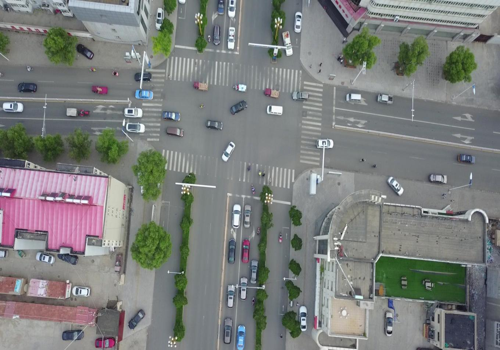

In [15]:
def ask_model(image_path, question, max_new_tokens=30):
    """Ask any custom question about any image path."""
    image = Image.open(image_path).convert("RGB")
    print("Question:", question)
    display_img = image.resize((500, 350))
    answer = generate_answer(model, processor, image, question, max_new_tokens=max_new_tokens)
    print("Model's answer:", answer)
    return display_img

# Example usage - change the index and question freely
test_path = os.path.join(val_images_dir, val_data[5]["image_filename"])
ask_model(test_path, "Is there a car in this image?")